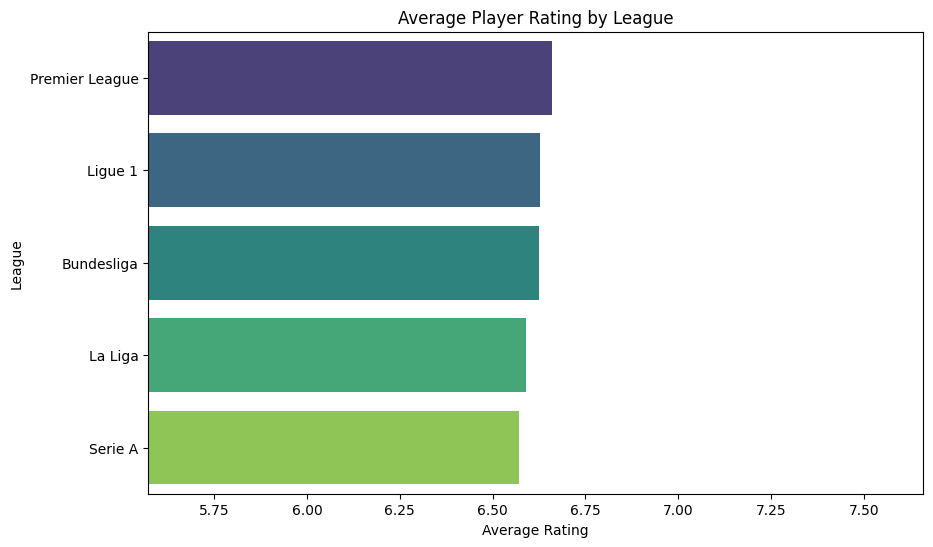

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset (replace with actual DataFrame)
# Assuming your DataFrame is called `df` and has a "League" and "Rating" column
# df = pd.read_csv("your_data.csv")  # Uncomment if loading from a file

# Group by league and calculate the mean rating
league_avg_rating = df.groupby("League")["Rating"].mean().reset_index()

# Sort by rating for better visualization
league_avg_rating = league_avg_rating.sort_values(by="Rating", ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=league_avg_rating, x="Rating", y="League", palette="viridis")

# Labels and title
plt.xlabel("Average Rating")
plt.ylabel("League")
plt.title("Average Player Rating by League")
plt.xlim(league_avg_rating["Rating"].min() - 1, league_avg_rating["Rating"].max() + 1)

# Show plot
plt.show()


In [8]:
import optuna
import xgboost as xgb
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("finalized_players.csv")
df = df.drop(columns=['Player Name'])  # Remove identifier column

# One-hot encode categorical columns
categorical_cols = ['Pos', 'Squad', 'League', 'Season']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Fill missing values
df = df.fillna(df.median())

# Drop Season columns if needed
df = df.drop(df.filter(like="Season").columns, axis=1)
df = df.drop(df.filter(like="Squad").columns, axis=1)
df = df.drop(df.filter(like="League").columns, axis=1)

# Split data into features (X) and target (y)
X = df.drop(columns=['Rating'])
y = df['Rating']
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Define Optuna objective function
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=100),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.2),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_loguniform('reg_alpha', 1e-3, 10.0),
        'reg_lambda': trial.suggest_loguniform('reg_lambda', 1e-3, 10.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10)
    }

    # Train model
    model = xgb.XGBRegressor(**params, random_state=42)
    model.fit(X_train, y_train)

    # Validate performance
    y_pred = model.predict(X_val)
    return r2_score(y_val, y_pred)

# Run Optuna optimization
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=200)

# Print best parameters
best_params = study.best_params
print("Best Hyperparameters:", best_params)

# Train final model with best parameters
best_model = xgb.XGBRegressor(**best_params, random_state=42)
best_model.fit(X_train, y_train)

# Evaluate performance on test set
y_pred_test = best_model.predict(X_test)
final_r2 = r2_score(y_test, y_pred_test)
final_mae = mean_absolute_error(y_test, y_pred_test)

print(f"Final R² Score: {final_r2:.4f}")
print(f"Final MAE: {final_mae:.4f}")


[I 2025-03-27 17:12:02,173] A new study created in memory with name: no-name-248c5773-7571-4944-8048-915fb04c9f60
C:\Users\qrJos\AppData\Local\Temp\ipykernel_17368\1896614092.py:35: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.2),
C:\Users\qrJos\AppData\Local\Temp\ipykernel_17368\1896614092.py:38: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'reg_alpha': trial.suggest_loguniform('reg_alpha', 1e-3, 10.0),
C:\Users\qrJos\AppData\Local\Temp\ipykernel_17368\1896614092.py:39: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optun

Best Hyperparameters: {'n_estimators': 700, 'max_depth': 3, 'learning_rate': 0.0605487138909333, 'subsample': 0.6177495307302218, 'colsample_bytree': 0.6524095821589513, 'reg_alpha': 0.6304827381123799, 'reg_lambda': 0.023966067481592194, 'min_child_weight': 8}
Final R² Score: 0.4673
Final MAE: 0.1421


Final Model MSE: 0.03788220555578391
Final R²: 0.35038978900937945


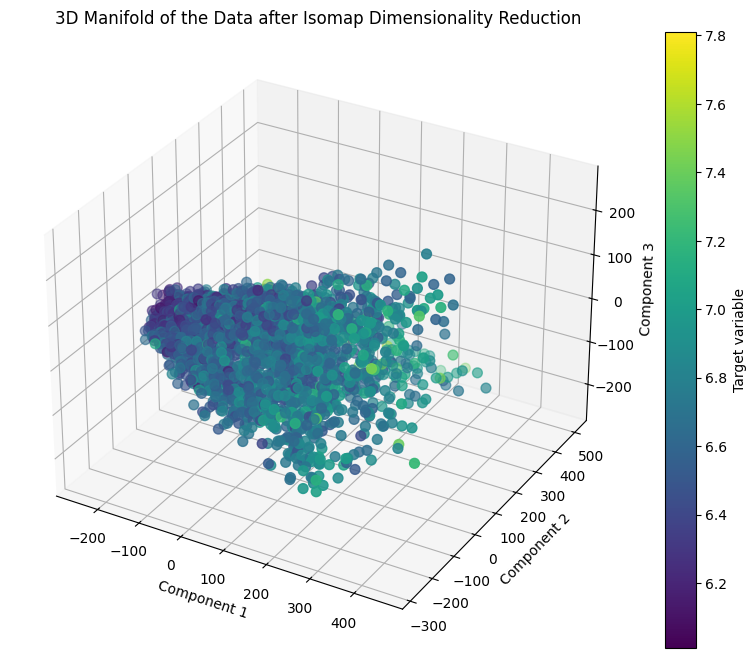

In [18]:
from sklearn.manifold import Isomap
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply Isomap for dimensionality reduction
n_neighbors = 5  # Number of neighbors for Isomap
n_components = 2  # Reduce to 2 components (you can experiment with this)

isomap = Isomap(n_neighbors=n_neighbors, n_components=n_components)
X_train_reduced = isomap.fit_transform(X_train)
X_val_reduced = isomap.transform(X_val)

# Initialize the GradientBoostingRegressor model with default parameters
model = GradientBoostingRegressor(random_state=42)

# Train the model with the reduced features
model.fit(X_train_reduced, y_train)

# Predict on the validation set
y_pred = model.predict(X_val_reduced)

# Evaluate the model performance
mse = mean_squared_error(y_val, y_pred)
r2 = model.score(X_val_reduced, y_val)

# Output the results
print(f'Final Model MSE: {mse}')
print(f'Final R²: {r2}')

import matplotlib.pyplot as plt
from sklearn.manifold import Isomap
from sklearn.model_selection import train_test_split
from mpl_toolkits.mplot3d import Axes3D

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply Isomap for dimensionality reduction
n_neighbors = 5  # Number of neighbors for Isomap
n_components = 3  # Reduce to 3 components

isomap = Isomap(n_neighbors=n_neighbors, n_components=n_components)
X_train_reduced = isomap.fit_transform(X_train)

# Plotting the 3D manifold after Isomap transformation
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot of the data
scatter = ax.scatter(X_train_reduced[:, 0], X_train_reduced[:, 1], X_train_reduced[:, 2], c=y_train, cmap='viridis', s=50)

# Add color bar for the target variable
colorbar = fig.colorbar(scatter, ax=ax)
colorbar.set_label('Target variable')

# Labels and title
ax.set_title('3D Manifold of the Data after Isomap Dimensionality Reduction')
ax.set_xlabel('Component 1')
ax.set_ylabel('Component 2')
ax.set_zlabel('Component 3')

plt.show()

In [25]:
import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Define the objective function for Optuna optimization
def objective(trial):
    # Hyperparameter search space
    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    max_depth = trial.suggest_int('max_depth', 3, 20)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 20)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    
    # Split the data into training and validation sets
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Initialize the RandomForestRegressor with trial parameters
    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42
    )
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Predict on the validation set
    y_pred = model.predict(X_val)
    
    # Compute the R² score
    r2 = model.score(X_val, y_val)
    
    return r2  # We want to maximize R²

# Create an Optuna study and optimize
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

# Output the best trial's parameters and R² score
print("Best trial:")
trial = study.best_trial
print(f"R²: {trial.value}")
print(f"Best hyperparameters: {trial.params}")


[I 2025-03-27 17:35:12,555] A new study created in memory with name: no-name-19190a7b-fdc9-46ce-bc81-e13822b8a394
[I 2025-03-27 17:35:13,533] Trial 0 finished with value: 0.40623216708553433 and parameters: {'n_estimators': 89, 'max_depth': 10, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.40623216708553433.
[I 2025-03-27 17:35:14,861] Trial 1 finished with value: 0.4087818735507426 and parameters: {'n_estimators': 111, 'max_depth': 18, 'min_samples_split': 6, 'min_samples_leaf': 6, 'max_features': 'log2'}. Best is trial 1 with value: 0.4087818735507426.
[I 2025-03-27 17:35:21,319] Trial 2 finished with value: 0.43949507970413204 and parameters: {'n_estimators': 121, 'max_depth': 12, 'min_samples_split': 14, 'min_samples_leaf': 6, 'max_features': None}. Best is trial 2 with value: 0.43949507970413204.
[I 2025-03-27 17:35:22,123] Trial 3 finished with value: 0.40704245769622727 and parameters: {'n_estimators': 54, 'max_depth': 16,

Best trial:
R²: 0.4460635710633022
Best hyperparameters: {'n_estimators': 182, 'max_depth': 19, 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_features': None}


In [23]:
import warnings

# Ignore all warnings
warnings.filterwarnings("ignore")

Accuracy: 0.5718

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.64      0.63       237
           1       0.45      0.40      0.42       250
           2       0.63      0.68      0.65       244

    accuracy                           0.57       731
   macro avg       0.57      0.57      0.57       731
weighted avg       0.56      0.57      0.57       731



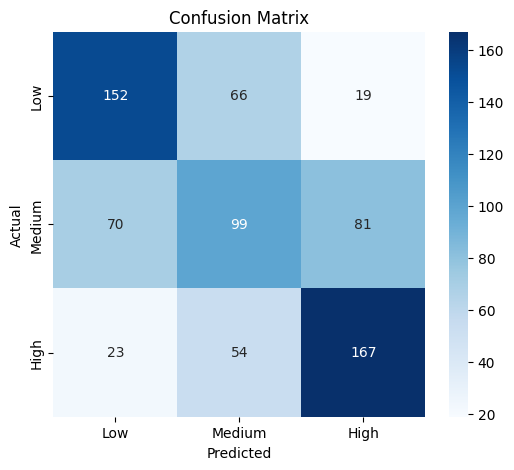

In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, KBinsDiscretizer
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset (assuming it's a DataFrame named df)
# df = pd.read_csv("path_to_your_data.csv")

# Feature Engineering (as defined before)
def feature_engineering(df):
    df['Defensive_Efficiency'] = (df['Tkl'] + df['Blocks'] + df['Int']) / df['90s']
    df['Offensive_Contribution'] = (df['Att 3rd'] + df['Crs'] + df['Sh']) / df['90s']
    df['Tactical_Contribution'] = df['TklW'] + (df['Tkl%'] * df['Tkl'])
    df['Penalty_Risk'] = (df['CrdY'] + df['CrdR'] + df['PKcon']) / df['90s']
    df['Defensive_Interaction'] = df['Tkl'] + df['Blocks'] + df['Int']
    #df['Seasonal_Trend'] = df.groupby('Season')['Rating'].transform(lambda x: x.diff()).fillna(0)
    df['Win_Ratio'] = df['Won'] / (df['Won'] + df['Lost'])
    return df

df = feature_engineering(df)

# Define features
features = ['Defensive_Efficiency', 'Offensive_Contribution', 'Tactical_Contribution', 
            'Penalty_Risk', 'Defensive_Interaction', 'Win_Ratio', '90s', 'Tkl', 'TklW', 
            'Def 3rd', 'Mid 3rd', 'Att 3rd', 'Chl-Tkl', 'Att', 'Tkl%', 'Chl-Lost', 'Blocks', 'Sh', 'Pass', 'Int', 
            'Tkl+Int', 'Clr', 'Err', 'CrdY', 'CrdR', '2CrdY', 'Fls', 'Off', 'Crs', 'PKcon', 'OG', 'Recov', 'Won', 'Lost']

X = df[features]
y = df['Rating']

# Convert Rating into Categories (Low, Medium, High)
num_bins = 3  # Adjust if needed
binning = KBinsDiscretizer(n_bins=num_bins, encode='ordinal', strategy='quantile')
y_binned = binning.fit_transform(y.values.reshape(-1, 1)).astype(int)  # Convert to integer classes

# Train-test split
X_train, X_val, y_train, y_val = train_test_split(X, y_binned, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# XGBoost Classifier with Given Parameters
xgb_clf = XGBClassifier(
    n_estimators=700,
    max_depth=3,
    learning_rate=0.0605487138909333,
    subsample=0.6177495307302218,
    colsample_bytree=0.6524095821589513,
    reg_alpha=0.6304827381123799,
    reg_lambda=0.023966067481592194,
    min_child_weight=8,
    random_state=42,
    use_label_encoder=False,
    eval_metric="mlogloss"
)

# Train the Model
xgb_clf.fit(X_train_scaled, y_train)

# Predictions
y_pred = xgb_clf.predict(X_val_scaled)

# Evaluate Model
accuracy = accuracy_score(y_val, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred))

# Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_val, y_pred), annot=True, fmt="d", cmap="Blues", xticklabels=["Low", "Medium", "High"], yticklabels=["Low", "Medium", "High"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


Validation R²: 0.4725 | MAE: 0.1300 | RMSE: 0.1705
Test R²: 0.4595 | MAE: 0.1420 | RMSE: 0.1814


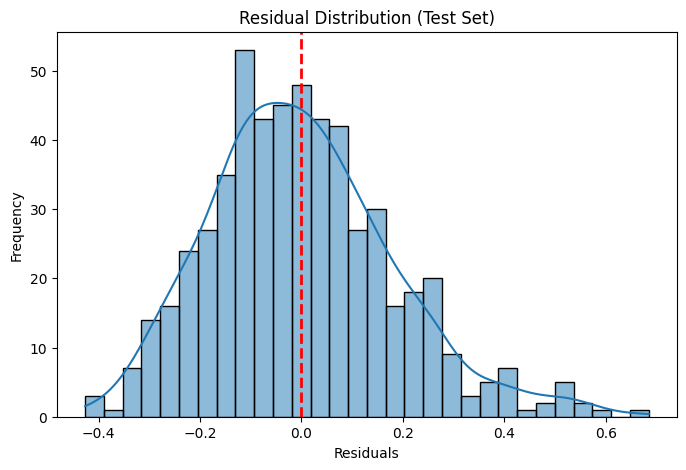

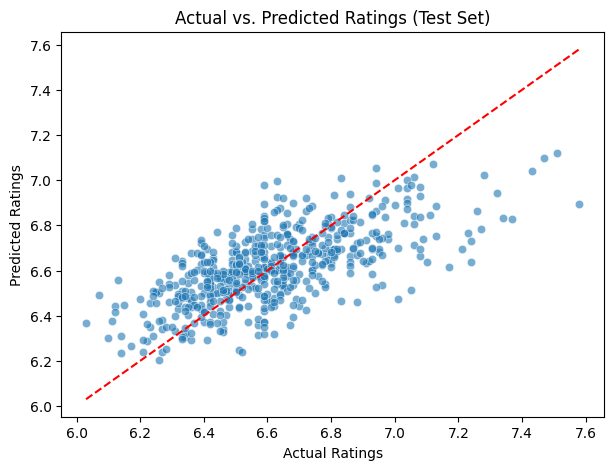

In [35]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset (assuming it's a DataFrame named df)
# df = pd.read_csv("path_to_your_data.csv")

# Feature Engineering
def feature_engineering(df):
    df['Defensive_Efficiency'] = (df['Tkl'] + df['Blocks'] + df['Int']) / df['90s']
    df['Offensive_Contribution'] = (df['Att 3rd'] + df['Crs'] + df['Sh']) / df['90s']
    df['Tactical_Contribution'] = df['TklW'] + (df['Tkl%'] * df['Tkl'])
    df['Penalty_Risk'] = (df['CrdY'] + df['CrdR'] + df['PKcon']) / df['90s']
    df['Defensive_Interaction'] = df['Tkl'] + df['Blocks'] + df['Int']
    #df['Seasonal_Trend'] = df.groupby('Season')['Rating'].transform(lambda x: x.diff()).fillna(0)
    df['Win_Ratio'] = df['Won'] / (df['Won'] + df['Lost'])
    return df

df = feature_engineering(df)

# Define features and target variable
features = ['Defensive_Efficiency', 'Offensive_Contribution', 'Tactical_Contribution', 
            'Penalty_Risk', 'Defensive_Interaction', 'Win_Ratio', '90s', 'Tkl', 'TklW', 
            'Def 3rd', 'Mid 3rd', 'Att 3rd', 'Chl-Tkl', 'Att', 'Tkl%', 'Chl-Lost', 'Blocks', 'Sh', 'Pass', 'Int', 
            'Tkl+Int', 'Clr', 'Err', 'CrdY', 'CrdR', '2CrdY', 'Fls', 'Off', 'Crs', 'PKcon', 'OG', 'Recov', 'Won', 'Lost']

X = df[features]
y = df['Rating']

# Split into train (70%), validation (15%), test (15%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# XGBoost Regressor with Given Parameters
xgb_reg = XGBRegressor(
    n_estimators=700,
    max_depth=3,
    learning_rate=0.0605487138909333,
    subsample=0.6177495307302218,
    colsample_bytree=0.6524095821589513,
    reg_alpha=0.6304827381123799,
    reg_lambda=0.023966067481592194,
    min_child_weight=8,
    random_state=42
)

# Train the Model
xgb_reg.fit(X_train_scaled, y_train)

# Predictions
y_val_pred = xgb_reg.predict(X_val_scaled)
y_test_pred = xgb_reg.predict(X_test_scaled)

# Evaluate Model
def evaluate_model(y_true, y_pred, dataset_name):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{dataset_name} R²: {r2:.4f} | MAE: {mae:.4f} | RMSE: {rmse:.4f}")

evaluate_model(y_val, y_val_pred, "Validation")
evaluate_model(y_test, y_test_pred, "Test")

# Plot Residuals
residuals = y_test - y_test_pred

plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=30, kde=True)
plt.axvline(0, color='r', linestyle='dashed', linewidth=2)
plt.title("Residual Distribution (Test Set)")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

# Scatter Plot of Predictions vs Actuals
plt.figure(figsize=(7, 5))
sns.scatterplot(x=y_test, y=y_test_pred, alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='dashed')
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs. Predicted Ratings (Test Set)")
plt.show()


In [34]:
import optuna
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from itertools import compress

# Feature names (adjust based on your dataset)
feature_names = [
    "90s", "Tkl", "TklW", "Def 3rd", "Mid 3rd", "Att 3rd", "Chl-Tkl", "Att", "Tkl%",
    "Chl-Lost", "Blocks", "Sh", "Pass", "Int", "Tkl+Int", "Clr", "Err", "CrdY",
    "CrdR", "2CrdY", "Fls", "Off", "Crs", "PKcon", "OG", "Recov", "Won", "Lost",
    "Won%", "Season"
]

# Train/test split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Standardize data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Optuna objective function
def objective(trial):
    # Feature selection (randomly choose features)
    selected_features = [trial.suggest_categorical(f"feature_{i}", [0, 1]) for i in range(len(feature_names))]
    
    # If all features are removed, force at least one to be included
    if sum(selected_features) == 0:
        return -np.inf
    
    # Apply feature mask
    X_train_selected = X_train_scaled[:, selected_features]
    X_val_selected = X_val_scaled[:, selected_features]
    
    # Hyperparameters
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10)
    }
    
    # Train model
    model = XGBRegressor(**params, random_state=42)
    model.fit(X_train_selected, y_train)
    
    # Validate model
    y_val_pred = model.predict(X_val_selected)
    
    # Return R² score
    return r2_score(y_val, y_val_pred)

# Run Optuna study
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

# Get best features
best_feature_mask = [study.best_trial.params[f"feature_{i}"] for i in range(len(feature_names))]
best_features = list(compress(feature_names, best_feature_mask))

print("Best Features:", best_features)
print("Best Hyperparameters:", study.best_params)
print("Best R² Score:", study.best_value)


[I 2025-03-27 17:52:12,853] A new study created in memory with name: no-name-ca0aef23-05a6-4b79-896f-7fcfcceba8d3
[I 2025-03-27 17:52:13,255] Trial 0 finished with value: 0.04809798835668144 and parameters: {'feature_0': 1, 'feature_1': 1, 'feature_2': 1, 'feature_3': 1, 'feature_4': 1, 'feature_5': 1, 'feature_6': 1, 'feature_7': 0, 'feature_8': 0, 'feature_9': 1, 'feature_10': 1, 'feature_11': 1, 'feature_12': 0, 'feature_13': 0, 'feature_14': 0, 'feature_15': 1, 'feature_16': 0, 'feature_17': 0, 'feature_18': 0, 'feature_19': 1, 'feature_20': 0, 'feature_21': 1, 'feature_22': 1, 'feature_23': 1, 'feature_24': 1, 'feature_25': 0, 'feature_26': 0, 'feature_27': 0, 'feature_28': 1, 'feature_29': 1, 'n_estimators': 127, 'max_depth': 7, 'learning_rate': 0.010751430135072109, 'subsample': 0.9312922887467718, 'colsample_bytree': 0.9373404180479655, 'reg_alpha': 0.5938565447709615, 'reg_lambda': 0.3322652570145682, 'min_child_weight': 5}. Best is trial 0 with value: 0.04809798835668144.
[I 

In [45]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
from itertools import permutations
import numpy as np

df.dropna(inplace=True)

# Drop non-numeric columns (assuming Player Name, Pos, Squad, League, and Season are not useful for modeling)
X = df.drop(columns=['Rating', 'Player Name', 'Squad', 'Season', 'League', 'Pos'])

# Ensure 'y' is just the target column (Rating)
y = df['Rating']

# Step 1: Split the data into 5 parts
X_splits = np.array_split(X, 5)
y_splits = np.array_split(y, 5)

# Step 2: Generate all possible combinations of 3 training folds, 1 validation fold, and 1 test fold
splits = list(permutations(range(5), 3))  # Generates all combinations of 3 training folds from 5

# Store results
results = []
val_mse = []
test_mse = []

# Step 3: Perform cross-validation for each combination of splits
for train_indices in splits:
    val_indices = [i for i in range(5) if i not in train_indices]  # Remaining fold is validation
    test_indices = val_indices[-1:]  # Last one will be the test fold
    val_indices = val_indices[:-1]  # The other will be the validation fold

    # Combine the training data from the selected splits
    X_train = pd.concat([X_splits[i] for i in train_indices], axis=0)
    y_train = pd.concat([y_splits[i] for i in train_indices], axis=0)

    # Validation data
    X_val = X_splits[val_indices[0]]
    y_val = y_splits[val_indices[0]]

    # Test data
    X_test = X_splits[test_indices[0]]
    y_test = y_splits[test_indices[0]]

    # Step 4: Initialize the XGBoost Regressor (use the best hyperparameters if already known)
    model = xgb.XGBRegressor(
        n_estimators=700,
        max_depth=3,
        learning_rate=0.0605487138909333,
        subsample=0.6177495307302218,
        colsample_bytree=0.6524095821589513,
        reg_alpha=0.6304827381123799,
        reg_lambda=0.023966067481592194,
        min_child_weight=8,
        random_state=42
    )

    # Step 5: Train the model
    model.fit(X_train, y_train)

    # Step 6: Predict on the validation fold
    y_val_pred = model.predict(X_val)
    val_r2 = r2_score(y_val, y_val_pred)

    # Step 7: Predict on the test fold
    y_test_pred = model.predict(X_test)
    test_r2 = r2_score(y_test, y_test_pred)

    # Calculate MSE for validation and test
    val_mse_fold = mean_squared_error(y_val, y_val_pred)
    test_mse_fold = mean_squared_error(y_test, y_test_pred)

    # Append MSE values
    val_mse.append(val_mse_fold)
    test_mse.append(test_mse_fold)

    # Store the results (R² values)
    results.append({
        'train_folds': train_indices,
        'val_fold': val_indices[0],
        'test_fold': test_indices[0],
        'val_r2': val_r2,
        'test_r2': test_r2,
        'val_mse': val_mse_fold,
        'test_mse': test_mse_fold
    })

# Step 8: Summarize the results
results_df = pd.DataFrame(results)
print(results_df)

# Optionally, you can take the average of the R² and MSE across all splits
average_val_r2 = results_df['val_r2'].mean()
average_test_r2 = results_df['test_r2'].mean()
average_val_mse = results_df['val_mse'].mean()
average_test_mse = results_df['test_mse'].mean()

print(f"Average Validation R² across all splits: {average_val_r2:.4f}")
print(f"Average Test R² across all splits: {average_test_r2:.4f}")
print(f"Average Validation MSE across all splits: {average_val_mse:.4f}")
print(f"Average Test MSE across all splits: {average_test_mse:.4f}")


   train_folds  val_fold  test_fold    val_r2   test_r2   val_mse  test_mse
0    (0, 1, 2)         3          4  0.478874  0.534475  0.030755  0.027522
1    (0, 1, 3)         2          4  0.444804  0.536705  0.028898  0.027391
2    (0, 1, 4)         2          3  0.443352  0.466520  0.028973  0.031484
3    (0, 2, 1)         3          4  0.475988  0.529547  0.030925  0.027814
4    (0, 2, 3)         1          4  0.465750  0.543645  0.032599  0.026980
5    (0, 2, 4)         1          3  0.479286  0.482162  0.031773  0.030561
6    (0, 3, 1)         2          4  0.446185  0.540234  0.028826  0.027182
7    (0, 3, 2)         1          4  0.473992  0.520398  0.032096  0.028355
8    (0, 3, 4)         1          2  0.497608  0.464236  0.030655  0.027886
9    (0, 4, 1)         2          3  0.433233  0.471106  0.029500  0.031213
10   (0, 4, 2)         1          3  0.478891  0.474435  0.031797  0.031017
11   (0, 4, 3)         1          2  0.498045  0.454293  0.030628  0.028404
12   (1, 0, 

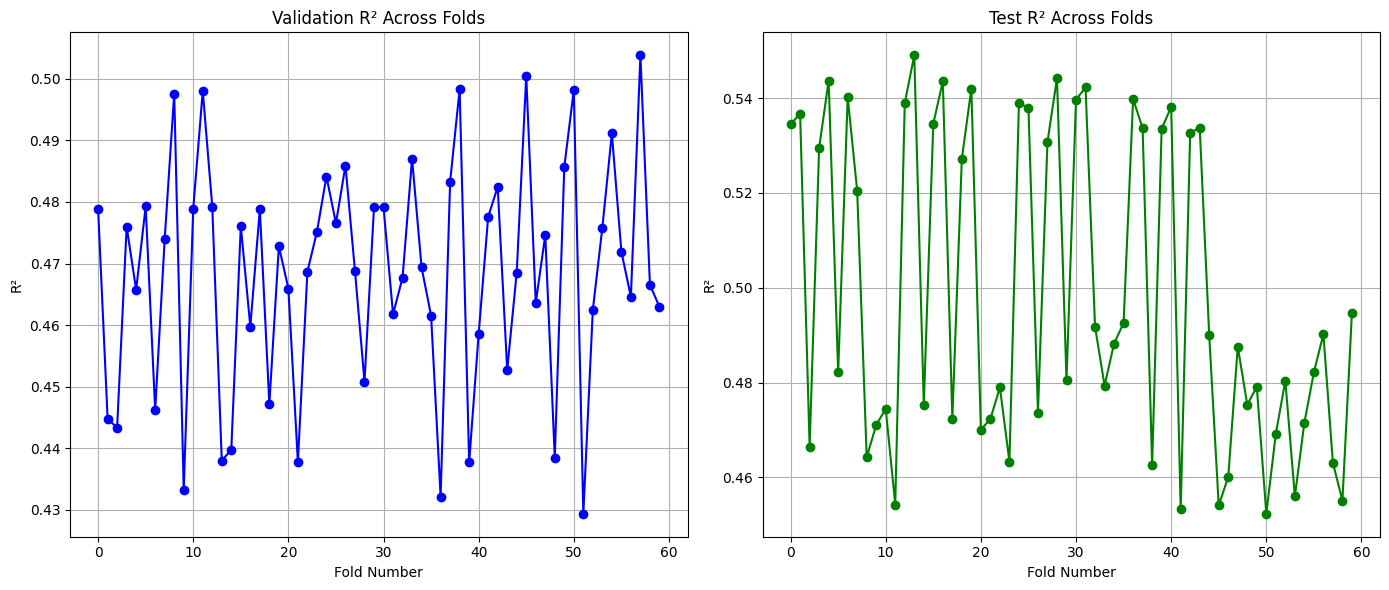

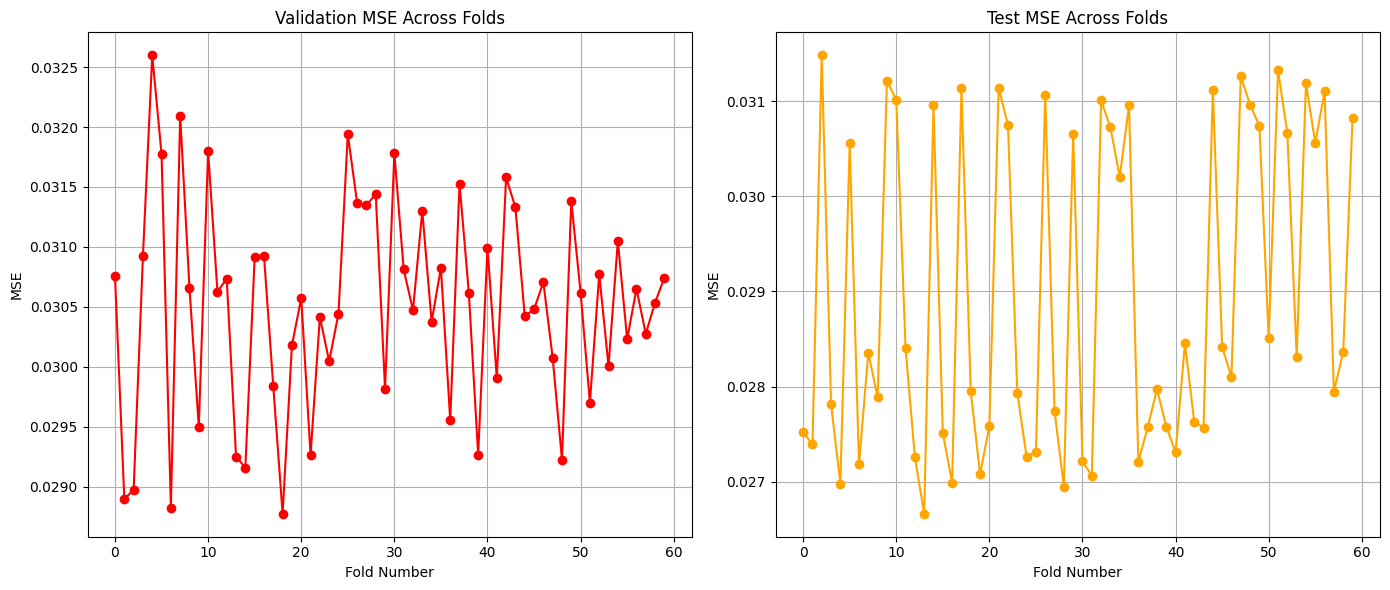

In [51]:
import matplotlib.pyplot as plt

# Plot R² scores for validation and test sets
plt.figure(figsize=(14, 6))

# Plot for Validation R²
plt.subplot(1, 2, 1)
plt.plot(results_df['val_r2'], marker='o', linestyle='-', color='b', label='Validation R²')
plt.title('Validation R² Across Folds')
plt.xlabel('Fold Number')
plt.ylabel('R²')
plt.grid(True)

# Plot for Test R²
plt.subplot(1, 2, 2)
plt.plot(results_df['test_r2'], marker='o', linestyle='-', color='g', label='Test R²')
plt.title('Test R² Across Folds')
plt.xlabel('Fold Number')
plt.ylabel('R²')
plt.grid(True)

plt.tight_layout()
plt.show()

# Plot MSE for validation and test sets
plt.figure(figsize=(14, 6))

# Plot for Validation MSE
plt.subplot(1, 2, 1)
plt.plot(results_df['val_mse'], marker='o', linestyle='-', color='r', label='Validation MSE')
plt.title('Validation MSE Across Folds')
plt.xlabel('Fold Number')
plt.ylabel('MSE')
plt.grid(True)

# Plot for Test MSE
plt.subplot(1, 2, 2)
plt.plot(results_df['test_mse'], marker='o', linestyle='-', color='orange', label='Test MSE')
plt.title('Test MSE Across Folds')
plt.xlabel('Fold Number')
plt.ylabel('MSE')
plt.grid(True)

plt.tight_layout()
plt.show()


ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH

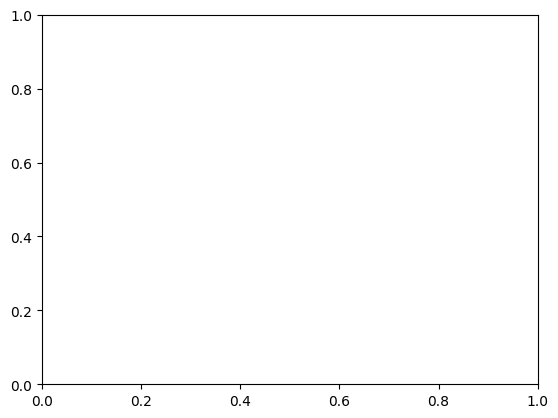

In [55]:
xgb.plot_tree(model, num_trees=0)  # Plot the first tree (you can change the number)
plt.show()

In [50]:
pip install graphviz

   ---------------------------------------- 0.0/47.1 kB ? eta -:--:--
   ----------------- ---------------------- 20.5/47.1 kB 640.0 kB/s eta 0:00:01
   ---------------------------------------- 47.1/47.1 kB 784.8 kB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: C:\Users\qrJos\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
